In [41]:
import os
# allows us to interact with the operating system (creating folders, building file paths, etc.) which we use below to make sure our output directory exists
import numpy as np
# allows us to use numpy, which gives us fast array/numeric operations that pandas and sklearn build on top of
import pandas as pd
# allows us to use the pandas package in python which we will use for data analysis and manipulation
import matplotlib.pyplot as mattyp
import matplotlib.ticker as ticker
# allows us to use matplotlib's pyplot submodule to get a matlab-like interface, which we will use for data visualization
import seaborn as sns
# allows us to use seaborn, a plotting library built on top of matplotlib that gives us cleaner statistical visualizations (histograms, heatmaps, etc.) with less code
os.makedirs('../Visualizations', exist_ok=True)
# creates the '../Visualizations' folder if it doesn't already exist, so any files we save there later (e.g., saved figures) won't fail due to a missing directory
# exist_ok=True prevents an error from being raised if the folder is already there

In [42]:
financial_fraud = pd.read_csv('../data/PS_20174392719_1491204439457_log.csv')
# reads the csv file into a pandas DataFrame, giving us our main working dataset for the rest of the notebook

In [43]:
financial_fraud.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [44]:
financial_fraud.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [45]:
financial_fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [46]:
financial_fraud.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

confirms no null values 

In [47]:
financial_fraud.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


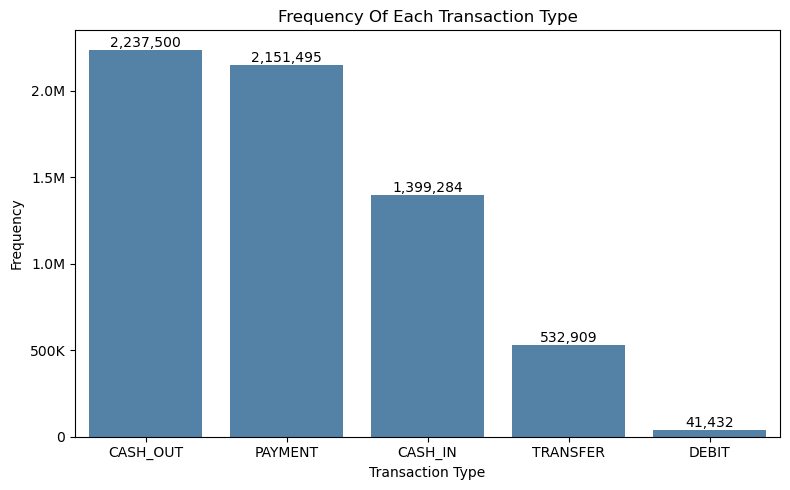

In [ ]:
# ============================================================
# SECTION 1: UNIVARIATE ANALYSIS
# ------------------------------------------------------------
# Definition: Univariate analysis examines one variable at a time, 
# in isolation from all others its distribution, central tendency, 
# spread, and any anomalies.
#
# What we're looking for: Shape of the distribution (normal, skewed, bimodal), 
# presence of outliers, class imbalance in categorical columns and unexpected values (negative amounts, impossible balances).
# ============================================================

# 1a. Distribution of transaction type (categorical)
fig, ax = mattyp.subplots(figsize=(8, 5))
# creates a single figure and axes object sized 8 by 5 inches
# fig is the overall figure container, ax is the specific plot area we draw onto below

sns.countplot(data=financial_fraud, x='type', color='steelblue', order=financial_fraud['type'].value_counts().index,ax=ax)
# draws a bar chart counting how many rows fall into each 'type' category
# order= sorts the bars from most frequent to least frequent, using value_counts to determine that order
# ax=ax tells seaborn to draw onto our explicit axes object instead of an implicit current one

# Format xy-axis ticks as readable K/M values instead of raw integers
def readable_xyvalues(num, pos):
    # a formatter function matplotlib will call once per y-axis tick
    # num is the raw tick value (e.g. 2000000), pos is its position index on the axis
    if num >= 1_000_000:
        return f'{num / 1_000_000:.1f}M'
        # if the value is a million or more, divide by a million and label it with 'M'
    elif num >= 1_000:
        return f'{num / 1_000:.0f}K'
         # if the value is a thousand or more (but under a million), divide by a thousand and label it with 'K'
    return f'{int(num)}'
    # anything smaller than 1,000 is shown as a plain integer, no letter needed

ax.yaxis.set_major_formatter(ticker.FuncFormatter(readable_yvalues)) 
# hands our formatter function to the y-axis so every tick label runs through it
# before being drawn, converting raw counts into readable K/M values  

ax.bar_label(ax.containers[0], labels=[f'{int(v.get_height()):,}' for v in ax.containers[0]])
# Add exact counts on top of each bar, formatted with thousands separators
# ax.containers[0] holds the bar objects seaborn drew; we loop through them,
# grab each bar's height (the count), and format it with comma separators for readability
ax.set_title('Frequency Of Each Transaction Type')
# sets the chart title
ax.set_xlabel('Transaction Type')
# labels the x-axis
ax.set_ylabel('Frequency')
# labels the y-axis
mattyp.tight_layout()
# automatically adjusts spacing so the title, labels, and bar-top counts don't get cut off or overlap
mattyp.savefig('../Visualizations/01univariate_type.png')
# saves the figure as a PNG file into the Visualizations folder
mattyp.show()
# displays the figure in the notebook's output so it renders when the notebook is viewed
mattyp.close(fig)
# closes this specific figure object to free up memory and prevent it from
# interfering with the next plot created later in the noteboo

Cash_Out is the most commom transaction with over 2.2 million entries, Payment is next with 2.1 million. The least common transction type is Debit 41,432 entries, several times smaller than the top two categories.

In [ ]:
# 1b. Class imbalance check for isFraud
print(financial_fraud['isFraud'].value_counts(normalize=True) * 100)
# value_counts() counts how many rows fall into each unique value of isFraud (0 or 1)
# normalize=True converts those raw counts into proportions (fractions of the whole) instead of counts
# multiplying by 100 converts those proportions into percentages, so the output reads directly.


isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


Over 99.87% of entries in this dataset are not fraudulent, while only about 0.13% are confirming a severe class imbalance. This is expected for real world fraud data, where fraudulent transactions are rare relative to legitimate ones, but it means accuracy alone would be a misleading metric for evaluating a classifier here. Metrics like F1 score, which balance precision and recall, will be far more informative given how few positive (fraud) examples exist to learn from.

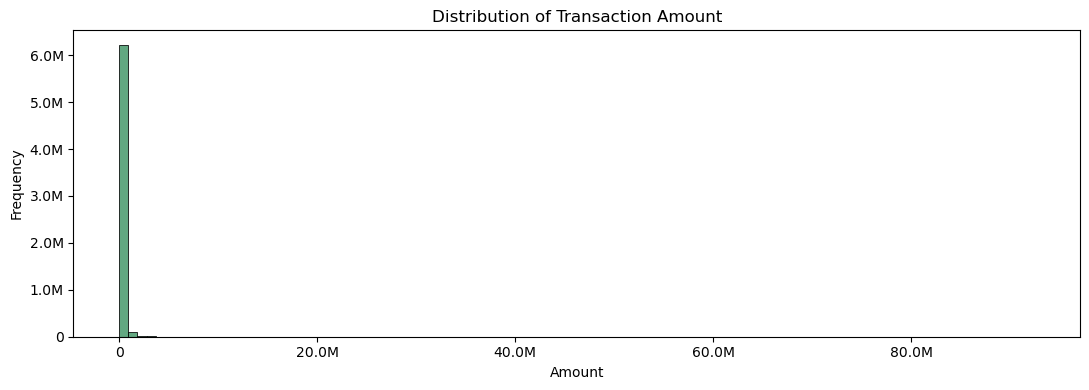

In [ ]:
# 1c. Histogram of Transaction Amount
fig, ax = mattyp.subplots(figsize=(11, 4))
# creates a single figure and axes object sized 11 by 4 inches
# fig is the overall figure container, ax is the specific plot area we draw onto below
sns.histplot(financial_fraud['amount'], bins=100, color='seagreen', ax=ax)
# draws a histogram of the raw 'amount' column, splitting the range into 100 bins
# ax=ax tells seaborn to draw onto our explicit axes object instead of an implicit current one
ax.xaxis.set_major_formatter(ticker.FuncFormatter(readable_xyvalues))
# hands our reusable formatter function to the x-axis so every tick label runs through it
# before being drawn, converting raw dollar amounts (like 20000000) into readable K/M values
ax.yaxis.set_major_formatter(ticker.FuncFormatter(readable_xyvalues))
# same formatter applied to the y-axis, since frequency counts on this dataset also run into
# the millions and would otherwise print as long unreadable raw integers
ax.set_title('Distribution of Transaction Amount')
# sets the chart title
ax.set_xlabel('Amount $')
# labels the x-axis, noting these are dollar values
ax.set_ylabel('Frequency')
# labels the y-axis
mattyp.tight_layout()
# automatically adjusts spacing so the title and axis labels don't get cut off or overlap
mattyp.savefig('../Visualizations/02histo_trans_amount.png')
# saves the figure as a PNG file into the Visualizations folder
mattyp.show()
# displays the figure in the notebook's output so it renders when the notebook is viewed
mattyp.close(fig)
# closes this specific figure object to free up memory and prevent it from
# interfering with the next plot created later in the notebook

raw amount is too skewed to interpret visually, which is why a log transform is applied in the next step,

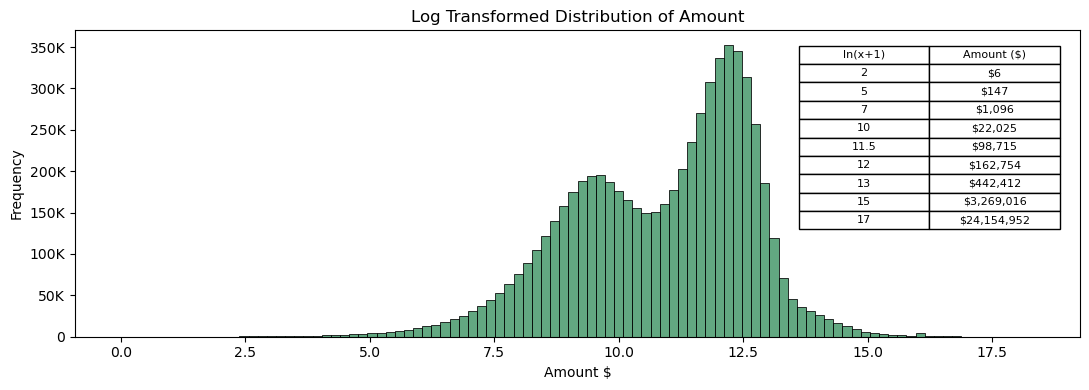

In [ ]:
# 1d. Log Transformed Histogram of Transaction Amount
fig, ax = mattyp.subplots(figsize=(11, 4))
sns.histplot(np.log1p(financial_fraud['amount']), bins=100, color='seagreen', ax=ax)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(readable_xyvalues))
# reuses the same readable_xyvalues function defined in 1a

ax.set_title('Log Transformed Distribution of Amount')
ax.set_xlabel('Amount')
ax.set_ylabel('Frequency')
# Reference table translating log1p(x) values back to real dollar amounts
# Placed in the upper-right corner so it doesn't overlap the main distribution shape
conversion_data = [
    ['2', '$6'],
    ['5', '$147'],
    ['7', '$1,096'],
    ['10', '$22,025'],
    ['11.5', '$98,715'],
    ['12', '$162,754'],
    ['13', '$442,412'],
    ['15', '$3,269,016'],
    ['17', '$24,154,952'],
]

ref_table = ax.table(cellText=conversion_data,
                      colLabels=['ln(x+1)', 'Amount ($)'],
                      bbox=[0.72, 0.35, 0.26, 0.6],  # [x, y, width, height] in axes-relative coords
                      cellLoc='center')
ref_table.auto_set_font_size(False)
ref_table.set_fontsize(8)
mattyp.tight_layout()
mattyp.savefig('../Visualizations/03histo_logtrans_amount.png')
mattyp.show()
mattyp.close(fig)

Most of the transactions that take place are between $1,096 and $162,754. Or between x = 7-12 on our log scale. Anything outside this scale the tiny transactions under a few hundred dollars, and the rare multi million dollar transfers makes up a very small slice of total volume, even though on the raw (non log) histogram those extreme values were what visually dominated the chart because of their sheer size, not their frequency.

This is a good insight to answer future questions, the log transformation reveals that typical transaction behavior is concentrated in the four to six figure range, while the raw distribution's mean (~$180K) and especially its max (~$92M) were being pulled way up by a small number of extreme outliers.

While preparing the log transformed histogram of amount, I noticed a small number of rows have a transaction amount of exactly $0 these had to be handled separately since a log transform can't process zero values. Before deciding how to treat them, I wanted to confirm exactly how many zero amount transactions exist in the dataset.

In [ ]:
# How many zero-amount transactions exist in total?
(financial_fraud['amount'] == 0).sum()
# creates a boolean mask where each row is True if 'amount' equals exactly 0, False otherwise
# .sum() then adds up all the True values (treated as 1) to get a total count of zero-amount rows

np.int64(16)

Only 16 transactions have an amount of exactly $0 a very minuscule. Next I will investigate the type breakdown of these transactions to see if I can gain further insight. 

In [ ]:
# Look at the actual rows before summarizing anything
financial_fraud[financial_fraud['amount'] == 0][['type', 'isFraud', 'oldbalanceOrg', 'newbalanceOrig']]
#financial_fraud['amount'] = 0 creates a boolean mask flagging every row where amount is exactly 0.
#financial_fraud[...] uses that mask to filter the dataframe down to only those 16 rows
#[['type', 'isFraud', 'oldbalanceOrg', 'newbalanceOrig']] selects just these four columns to display, rather than all 11, so the output is easy to scan visually for a pattern

,type,isFraud,oldbalanceOrg,newbalanceOrig
2736447,CASH_OUT,1,0.0,0.0
3247298,CASH_OUT,1,0.0,0.0
3760289,CASH_OUT,1,0.0,0.0
5563714,CASH_OUT,1,0.0,0.0
5996408,CASH_OUT,1,0.0,0.0
5996410,CASH_OUT,1,0.0,0.0
6168500,CASH_OUT,1,0.0,0.0
6205440,CASH_OUT,1,0.0,0.0
6266414,CASH_OUT,1,0.0,0.0
6281483,CASH_OUT,1,0.0,0.0


Further investigation revealed that all 16 of these 0 amount transactions are of the type CASH_OUT, and all 16 are labeled as fraud (isFraud = 1). That's a 100% fraud rate within this tiny subset, compared to the dataset's overall fraud rate of just 0.13%. This suggests that a 0 dollar CASH_OUT transaction is a strong, near certain fraud signal in this simulation rather and it's a pattern worth preserving (and potentially engineering into an explicit feature) rather than removing during cleaning.

In [62]:
# Step 3: Confirm the pattern numerically
zero_amt = financial_fraud[financial_fraud['amount'] == 0]
print(zero_amt['type'].value_counts())
# prints value counts for the type column
print(zero_amt['isFraud'].value_counts())
# prints value counts for the isFraud column


type
CASH_OUT    16
Name: count, dtype: int64
isFraud
1    16
Name: count, dtype: int64


All 16 0 amount transactions are of the type CASH_OUT, and all 16 are labeled as fraud (isFraud = 1) a 100% fraud rate within this subset. This is abmormal compared to the dataset's overall fraud rate of roughly 0.13%. This confirms that amount = 0 combined with type the CASH_OUT is a strong, non random fraud pattern.

In [63]:
# Check balances for any additional pattern
print(zero_amt[['oldbalanceOrg', 'newbalanceOrig']].describe())

       oldbalanceOrg  newbalanceOrig
count           16.0            16.0
mean             0.0             0.0
std              0.0             0.0
min              0.0             0.0
25%              0.0             0.0
50%              0.0             0.0
75%              0.0             0.0
max              0.0             0.0
